In [1]:
using LinearAlgebra
using DifferentialEquations
using Plots
using PyCall
using NonlinearEigenproblems
include("CRD_STA.jl")

DevelopingSpatialMode (generic function with 1 method)

In [2]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
    # eigval = conj(eigval)
    return eigval,eigvec
end

eigsol (generic function with 1 method)

In [3]:
function BaseFlow(Re_s,mode)
    if mode == 1 
        py"""
        import numpy as np
        from scipy.integrate import solve_bvp
        import matplotlib.pyplot as plt
        import math
        from math import sqrt
        Re_s = $Re_s
        def oneDiskODE(z,y):
                # Y0 = H, Y1 = F,Y2 = F', Y3 = F'', Y4 = G, Y5 = G'
                dH = -2 * sqrt(Re_s) * y[1]
                dydz = np.zeros((6, len(z)))
                dydz = np.array([dH , y[2] , y[3] , Re_s * ( (1/sqrt(Re_s)) * ( y[3] * y[0] + y[2] * dH) - 2 * y[4] * y[5] + 2 * y[1] * y[2]) , y[5] , Re_s * ( (1/sqrt(Re_s)) * y[5] * y[0] + 2 * y[1] * y[4])])
                return dydz 

        def oneDiskBC(ya, yb):
                resa = np.array([ya[0],ya[1], ya[4] - 1])
                
                resb = np.array([yb[0],yb[1], yb[4] - 0])
                
                return np.concatenate((resa, resb))


        z = np.linspace(0, 1, 20000)
        y = np.zeros((6, len(z)))
        y_guess = np.zeros((6, z.size))
        y_guess[0] = 1
        y_guess[1] = 0
        y_guess[2] = 0
        y_guess[3] = 0
        y_guess[4] = 1
        y_guess[5] = 0
        solution = solve_bvp(oneDiskODE, oneDiskBC, z, y_guess,max_nodes=5000000)

        x_plot = np.linspace(0, 1, 20000)


        y1_plot = solution.sol(x_plot)[0]
        y2_plot = solution.sol(x_plot)[1]
        y3_plot = solution.sol(x_plot)[4]
        y4_plot = solution.sol(x_plot)[2]
        y5_plot = solution.sol(x_plot)[5]
        """
        w0 = py"y1_plot"
        u0 = py"y2_plot"
        v0 = py"y3_plot"
        du0 = py"y4_plot"
        dv0 = py"y5_plot"
        x = py"x_plot"
    elseif mode == 2
                py"""
        import numpy as np
        from scipy.integrate import solve_bvp
        import matplotlib.pyplot as plt
        kappa = -1
        def oneDiskODE(z, y):
        
                # Y0 = H, Y1 = F', Y2 = F, Y3 = G', Y4 = G
                dydz = np.zeros((5, len(z)))
                dydz = np.array([-2*y[2], y[2] * y[2] - y[4] * y[4] + y[0] * y[1], y[1], 2 * y[2] * y[4] + y[3] * y[0], y[3]])
                # dydz = np.array([-2.0 *y[2], kappa * (y[2] *y[2] + y[0] *y[1] -(y[4] *y[4]- 1.0)) -(2.0 -kappa - kappa**2) *(y[4] -1.0), y[1], 
                # kappa *(2.0 * y[2] *y[4] +y[0] *y[3]) +(2.0 -kappa -kappa**2) *y[2], y[3]])
                return dydz 
        
        def oneDiskBC(ya, yb):
                resa = np.array([ya[0],
                                ya[2],
                                ya[4]-1.0])
                
                resb = np.array([yb[2],
                                yb[4]])
                
                return np.concatenate((resa, resb))
        
        
        z = np.linspace(0, 30, 20000)
        y = np.zeros((5, len(z)))
        y_guess = np.zeros((5, z.size))
        y_guess[0] = 1.2
        y_guess[1] = 0
        y_guess[2] = 0
        y_guess[3] = 0
        y_guess[4] = 0
        solution = solve_bvp(oneDiskODE, oneDiskBC, z, y_guess,tol=1e-10,max_nodes=5000000)
        
        x_plot = np.linspace(0, 30, 20000)
        
        
        y1_plot = solution.sol(x_plot)[0]
        y2_plot = solution.sol(x_plot)[2]
        y3_plot = solution.sol(x_plot)[4]
        y4_plot = solution.sol(x_plot)[1]
        y5_plot = solution.sol(x_plot)[3]
        
        """
        w0 = py"y1_plot"
        u0 = py"y2_plot"
        v0 = py"y3_plot"
        du0 = py"y4_plot"
        dv0 = py"y5_plot"
        x = py"x_plot"
        end
        if mode == 3 
                py"""
        import numpy as np
        from scipy.integrate import solve_bvp
        kappa = -1
        def oneDiskODE(z, y):
        
                # Y0 = H, Y1 = F', Y2 = F, Y3 = G', Y4 = G
                dydz = np.zeros((5, len(z)))
                dydz = np.array([-
                                2.0*
                                y[2], kappa * 
                                (y[2] *
                                y[2] +
                                    y[0] *
                                    y[1] -
                                    (y[4] *
                                    y[4]- 
                                    1.0)) -
                                (2.0 -
                                    kappa - 
                                    kappa**2) *
                                (y[4] -
                                    1.0), y[1], kappa *
                                (2.0 * 
                                    y[2] *
                                    y[4] +
                                    y[0] *
                                    y[3]) +
                                (2.0 -
                                    kappa -
                                    kappa**2) *
                                y[2], y[3]])
                return dydz 
        
        def oneDiskBC(ya, yb):
                resa = np.array([ya[0],
                                ya[2],
                                ya[4]])
                
                resb = np.array([yb[2],
                                yb[4] - 1.0])
                
                return np.concatenate((resa, resb))
        
        
        z = np.linspace(0, 30, 20000)
        y = np.zeros((5, len(z)))
        y_guess = np.zeros((5, z.size))
        if kappa == 1:
                y_guess[0] = 1.2
                y_guess[1] = 0
                y_guess[2] = 0
                y_guess[3] = 0
                y_guess[4] = 1
        elif kappa == -1:
                y_guess[0] = 1.2
                y_guess[1] = 0
                y_guess[2] = 0
                y_guess[3] = 0
                y_guess[4] = 1
        else:
                y_guess[0] = 1.2
                y_guess[1] = 0
                y_guess[2] = 0
                y_guess[3] = 0
                y_guess[4] = 1
        
        
        
        
        solution = solve_bvp(oneDiskODE, oneDiskBC, z, y_guess,tol=1e-10,max_nodes=5000000)
        
        x_plot = np.linspace(0, 30, 20000)
        
        
        y1_plot = solution.sol(x_plot)[0]
        y2_plot = solution.sol(x_plot)[2]
        y3_plot = solution.sol(x_plot)[4]
        y4_plot = solution.sol(x_plot)[1]
        y5_plot = solution.sol(x_plot)[3]
        
        """
        w0 = py"y1_plot"
        u0 = py"y2_plot"
        v0 = py"y3_plot"
        du0 = py"y4_plot"
        dv0 = py"y5_plot"
        x = py"x_plot"
        end
    return u0,v0,w0,du0,dv0,x
end
function Cheb(N,mode)
    if mode == 1
        θ = range(0,length=N+1,stop=pi)
        x = reshape(-cos.(θ), N+1, 1)
        c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
        X = repeat(x, 1, N+1);
        dX = X - X';
        D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
        D = D - diagm(vec(sum(D, dims=2))); 
        D = 2 * D
        x = 0.5 * (x .+1) 
        D2 = D^2;
    elseif mode == 3
         θ = range(0,length=N+1,stop=pi)
        x = reshape(-cos.(θ), N+1, 1)
        c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
        X = repeat(x, 1, N+1);
        dX = X - X';
        D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
        D = D - diagm(vec(sum(D, dims=2))); 
        a = 2
        b = 0.6
        c = 0.5
        for i=1:N+1
            D[i,:]=D[i,:].* (1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))^2/(2a*(b .+ 3 * (1-b)*x[i]^2 - 2 * c * (1-b) * x[i]))
        end
        for i=1:N+1
            x[i] = a * (1+b*x[i]+(1-b)*(x[i]^3+c*(1-x[i]^2)))/(1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))
            if x[i] > 30
                x[i] = 30
            end
        end
        D2 = D^2;
        elseif mode == 2
            θ = range(0,length=N+1,stop=pi)
            x = reshape(-cos.(θ), N+1, 1)
            c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
            X = repeat(x, 1, N+1);
            dX = X - X';
            D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
            D = D - diagm(vec(sum(D, dims=2))); 
            a = 2
            b = 0.6
            c = 0.5
            for i=1:N+1
                D[i,:]=D[i,:].* (1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))^2/(2a*(b .+ 3 * (1-b)*x[i]^2 - 2 * c * (1-b) * x[i]))
            end
            for i=1:N+1
                x[i] = a * (1+b*x[i]+(1-b)*(x[i]^3+c*(1-x[i]^2)))/(1-b*x[i]-(1-b)*(x[i]^3+c*(1-x[i]^2)))
                if x[i] > 30
                    x[i] = 30
                end
            end
            D2 = D^2;
    end
    return D,D2,x
end
function interp(u0,v0,w0,x,N,mode)
        F = Base.zeros(N+1,1)
        G = Base.zeros(N+1,1)
        H = Base.zeros(N+1,1)
        T = Base.zeros(N+1,1)
        if mode ==1 
            z = range(0,1,20000)
            itu = BSplineKit.interpolate(z, u0 , BSplineOrder(4))
            itv = BSplineKit.interpolate(z, v0 , BSplineOrder(4))
            itw = BSplineKit.interpolate(z, w0 , BSplineOrder(4))
            for i = 1 : N + 1
                F[i,1] = itu(x[i])
                G[i,1] = itv(x[i])
                H[i,1] = itw(x[i])
            end
        elseif mode == 2
            z = range(0,30,20000)
            itu = BSplineKit.interpolate(z, u0 , BSplineOrder(4))
            itv = BSplineKit.interpolate(z, v0 , BSplineOrder(4))
            itw = BSplineKit.interpolate(z, w0 , BSplineOrder(4))
            for i = 1 : N + 1
                F[i,1] = itu(x[i])
                G[i,1] = itv(x[i])
                H[i,1] = itw(x[i])
            end
        elseif mode == 3
            z = range(0,30,20000)
            itu = BSplineKit.interpolate(z, u0 , BSplineOrder(4))
            itv = BSplineKit.interpolate(z, v0 , BSplineOrder(4))
            itw = BSplineKit.interpolate(z, w0 , BSplineOrder(4))
            for i = 1 : N + 1
                F[i,1] = itu(x[i])
                G[i,1] = itv(x[i])
                H[i,1] = itw(x[i])
            end
        end
    return F,G,H
end
function eig_full(eigvec,N_cheb,num)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,4N-6,0im)
    insert!(eigvec,3N-5,0im)
    insert!(eigvec,2N-3,0im)
    insert!(eigvec,2N-3,0im)
    insert!(eigvec,N-1,0im)
    insert!(eigvec,N-1,0im)
    insert!(eigvec,1,0im)
    u = eigvec[1:N]
    v = eigvec[N+1:2N]
    w = eigvec[2N+1:3N]
    p = eigvec[3N+1:4N]
    return (u,v,w,p)
end

eig_full (generic function with 1 method)

In [4]:
N = 20000
Res = 1000
N_cheb = 199
mode = 1
u0,v0,w0,du0,dv0,x = BaseFlow(Res,mode)
D,D2,z = Cheb(N_cheb,mode)
F,G,H = interp(u0,v0,w0,z,N_cheb,mode)

([-2.225936566031662e-21; 0.0009296813629846089; … ; -0.0003246756932249654; -5.576722345043049e-21;;], [1.0; 0.9989669503187375; … ; 0.0002665517429801234; -2.2346590430280908e-20;;], [-8.835242138475332e-29; -1.8328668859567941e-6; … ; -6.398218829499747e-7; 2.3884840187468674e-23;;])

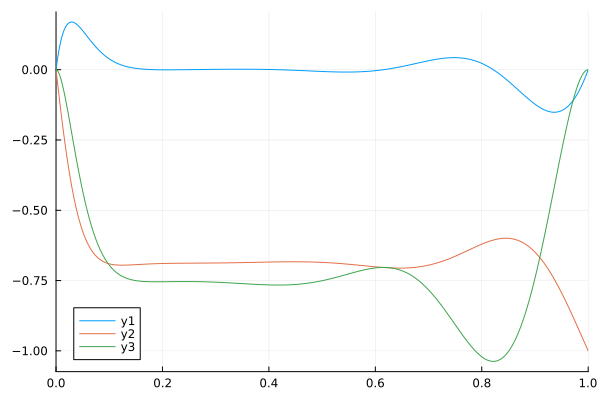

In [5]:
plot(z,F,xlim=[0,1])
plot!(z,G.-1)
plot!(z,H)

In [ ]:
R = 285.36
be = 0.07759
omega = 0.0
c = 0.4
cof = Spatial_mode_BEK2(F,(G.-1),H,R,N_cheb,D,D2)
# L0,L1,L2 = assemble_mat(cof,D,D2,be,omega,R)
L0_raw = cof.D1  + im * R * be * cof.B - im * omega * cof.Ta - be^2 * R^2 * cof.Vyy + (cof.C .+ im * be * R * cof.Vyz) * kron(I(4), D)  + (cof.Vzz) * kron(I(4),D2) 
L1_raw = im * cof.A - be * R * cof.Vxy + im *  cof.Vxz * kron(I(4),D)
L2_raw = -cof.Vxx 
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)
vel = eig_full(eigvec,N_cheb,1)
@show eigval

In [7]:
plot(z,abs.(vel[1]),label = "u",xlims=[0,1]) 
plot!(z,abs.(vel[2]),label = "v",xlims=[0,1])
plot!(z,abs.(vel[3]),label = "w")
plot!(z,abs.(vel[4]),label = "p")

UndefVarError: UndefVarError: `vel` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [8]:
A0,A1,A2 = test1(F,G,H,R,N_cheb,D,D2)
nep = PEP([A0,A1,A2]);
eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-12)    

UndefVarError: UndefVarError: `test1` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [12]:
struct COF
        Ta :: Matrix{ComplexF64}
        A :: Matrix{ComplexF64}
        B :: Matrix{ComplexF64}
        C :: Matrix{ComplexF64}
        dC :: Matrix{ComplexF64}
        D1 :: Matrix{ComplexF64}
        Vxx :: Matrix{ComplexF64}
        Vyy :: Matrix{ComplexF64}
        Vzz :: Matrix{ComplexF64}
        dVzz :: Matrix{ComplexF64}
        d2Vzz :: Matrix{ComplexF64}
        Vxy :: Matrix{ComplexF64}
        Vxz :: Matrix{ComplexF64}
        dVxz :: Matrix{ComplexF64}
        Vyz :: Matrix{ComplexF64}
        dVyz :: Matrix{ComplexF64}
end
function Spatial_mode_BEK2(F,G,H,R,N_cheb,D,D2)

    size = N_cheb + 1
    eye = I(N_cheb+1)
    Zero = zeros(N_cheb+1,N_cheb+1)
    Ta = zeros(4*size,4*size)
    A = zeros(4*size,4*size)
    B = zeros(4*size,4*size)
    C = zeros(4*size,4*size)
    D1 = zeros(4*size,4*size)
    Vxy = zeros(4*size,4*size)
    Vxz = zeros(4*size,4*size)
    Vyz = zeros(4*size,4*size)
    Vxx = zeros(4*size,4*size)
    Vyy = zeros(4*size,4*size)
    Vzz = zeros(4*size,4*size)
    dVxz = zeros(4*size,4*size)
    dVyz = zeros(4*size,4*size)
    Ta_11 = eye
    Ta_12 = Ta_13 = Ta_14 = Zero
    Ta_22 = eye
    Ta_21 = Ta_23 = Ta_24 = Zero
    Ta_33 = eye
    Ta_31 = Ta_32 = Ta_34 = Zero
    Ta_41 = Ta_42 = Ta_43 = Ta_44 = Zero

    A_11 = F .* eye
    A_12 = A_13 = Zero
    A_14 = eye
    A_22 = F .* eye
    A_21 = A_23 = A_24 = Zero
    A_31 = A_32 = A_34 = Zero
    A_33 = F .* eye
    A_41 = (1) .* eye
    A_42 = A_43 = A_44 = Zero

    B_11 = (1/R) * G .* eye
    B_12 = B_13 = B_14 = Zero
    B_21 = B_23 = Zero
    B_22 = (1/R) * G .* eye
    B_24 = (1/R) .* eye
    B_31 = B_32 = B_34 = Zero
    B_33 = (1/R) * G .* eye
    B_41 = B_43 = B_44 = Zero
    B_42 = (1/R) .* eye

    C_11 = (1/R) *H .* eye
    dC_11 = D * diag(C_11) .* eye
    C_12 = C_13 = C_14 = Zero
    dC_12 = dC_13 = dC_14 = Zero
    C_22 = (1/R) * H .* eye
    dC_22 = D * diag(C_22) .* eye
    C_21 = C_23 = C_24 = Zero
    dC_21 = dC_23 = dC_24 = Zero
    C_31 = C_32 = Zero
    dC_31 = dC_32 = Zero
    C_33 = (1/R) * H .* eye
    dC_33 = D * diag(C_33) .* eye
    C_34 = eye
    dC_34 = D * diag(C_34) .* eye
    C_41 = C_42 = C_44 = Zero
    dC_41 = dC_42 = dC_44 = Zero
    C_43 = eye
    dC_43 = D * diag(C_43) .* eye

    D_11 = (1/R) * F .* eye
    D_12 = -(2/R) * (G.+1) .* eye
    D_13 = D * F .* eye
    D_14 = Zero
    D_21 = (2/R) * (G.+1) .* eye
    D_22 = (1/R) * F .* eye
    D_23 = D*G .* eye
    D_24 = Zero
    D_31 = D_32 = D_34 = Zero
    D_33 = (1/R) * D*H.* eye
    D_41 = 1/R .* eye
    D_42 = D_43 = D_44 = Zero

    Vxx_11 = -(1/R) * eye
    Vxx_12 = Vxx_13 = Vxx_14 = Zero
    Vxx_22 = -(1/R) * eye
    Vxx_21 = Vxx_23 = Vxx_24 = Zero
    Vxx_33 = -(1/R) * eye
    Vxx_31 = Vxx_32 = Vxx_34 = Zero
    Vxx_41 = Vxx_42 = Vxx_43 = Vxx_44 = Zero

    Vyy_11 = -(1/R^3) * eye
    Vyy_12 = Vyy_13 = Vyy_14 = Zero
    Vyy_22 = -(1/R^3) * eye
    Vyy_21 = Vyy_23 = Vyy_24 = Zero
    Vyy_33 = -(1/R^3) * eye
    Vyy_31 = Vyy_32 = Vyy_34 = Zero
    Vyy_41 = Vyy_42 = Vyy_43 = Vyy_44 = Zero

    Vzz_11 = -(1/R) * eye
    dVzz_11 = D * diag(Vzz_11) .* eye
    d2Vzz_11 = D2 * diag(Vzz_11) .* eye
    Vzz_12 = Vzz_13 = Vzz_14 = Zero
    dVzz_12 = dVzz_13 = dVzz_14 = Zero
    d2Vzz_12 = d2Vzz_13 = d2Vzz_14 = Zero
    Vzz_22 = -(1/R) * eye
    dVzz_22 = D * diag(Vzz_22) .* eye
    d2Vzz_22 = D2 * diag(Vzz_22) .* eye
    Vzz_21 = Vzz_23 = Vzz_24 = Zero
    dVzz_21 = dVzz_23 = dVzz_24 = Zero
    d2Vzz_21 = d2Vzz_23 = d2Vzz_24 = Zero
    Vzz_33 = -(1/R) * eye
    dVzz_33 = D * diag(Vzz_33) .* eye
    d2Vzz_33 = D2 * diag(Vzz_33) .* eye
    Vzz_31 = Vzz_32 = Vzz_34 = Zero
    dVzz_31 = dVzz_32 = dVzz_34 = Zero
    d2Vzz_31 = d2Vzz_32 = d2Vzz_34 = Zero
    Vzz_41 = Vzz_42 = Vzz_43 = Vzz_44 = Zero
    dVzz_41 = dVzz_42 = dVzz_43 = dVzz_44 = Zero
    d2Vzz_41 = d2Vzz_42 = d2Vzz_43 = d2Vzz_44 = Zero

    Vxy = zeros(4*size,4*size)
    Vxz = zeros(4*size,4*size)
    Vyz = zeros(4*size,4*size)

    Ta = [Ta_11 Ta_12 Ta_13 Ta_14;Ta_21 Ta_22 Ta_23 Ta_24;Ta_31 Ta_32 Ta_33 Ta_34;Ta_41 Ta_42 Ta_43 Ta_44]
    A = [A_11 A_12 A_13 A_14;A_21 A_22 A_23 A_24;A_31 A_32 A_33 A_34;A_41 A_42 A_43 A_44]
    B = [B_11 B_12 B_13 B_14;B_21 B_22 B_23 B_24;B_31 B_32 B_33 B_34;B_41 B_42 B_43 B_44]
    C = [C_11 C_12 C_13 C_14;C_21 C_22 C_23 C_24;C_31 C_32 C_33 C_34;C_41 C_42 C_43 C_44]
    dC = [dC_11 dC_12 dC_13 dC_14;dC_21 dC_22 dC_23 dC_24;dC_31 dC_32 dC_33 dC_34;dC_41 dC_42 dC_43 dC_44]
    D1 = [D_11 D_12 D_13 D_14;D_21 D_22 D_23 D_24;D_31 D_32 D_33 D_34;D_41 D_42 D_43 D_44]
    Vxx = [Vxx_11 Vxx_12 Vxx_13 Vxx_14;Vxx_21 Vxx_22 Vxx_23 Vxx_24;Vxx_31 Vxx_32 Vxx_33 Vxx_34;Vxx_41 Vxx_42 Vxx_43 Vxx_44]
    Vyy = [Vyy_11 Vyy_12 Vyy_13 Vyy_14;Vyy_21 Vyy_22 Vyy_23 Vyy_24;Vyy_31 Vyy_32 Vyy_33 Vyy_34;Vyy_41 Vyy_42 Vyy_43 Vyy_44]
    Vzz = [Vzz_11 Vzz_12 Vzz_13 Vzz_14;Vzz_21 Vzz_22 Vzz_23 Vzz_24;Vzz_31 Vzz_32 Vzz_33 Vzz_34;Vzz_41 Vzz_42 Vzz_43 Vzz_44]
    dVzz = [dVzz_11 dVzz_12 dVzz_13 dVzz_14;dVzz_21 dVzz_22 dVzz_23 dVzz_24;dVzz_31 dVzz_32 dVzz_33 dVzz_34;dVzz_41 dVzz_42 dVzz_43 dVzz_44]
    d2Vzz = [d2Vzz_11 d2Vzz_12 d2Vzz_13 d2Vzz_14;d2Vzz_21 d2Vzz_22 d2Vzz_23 d2Vzz_24;d2Vzz_31 d2Vzz_32 d2Vzz_33 d2Vzz_34;d2Vzz_41 d2Vzz_42 d2Vzz_43 d2Vzz_44]
    return COF(Ta,A,B,C,dC,D1,Vxx,Vyy,Vzz,dVzz,d2Vzz,Vxy,Vxz,dVxz,Vyz,dVyz)
end
function assemble_mat(cof,D,D2,be,omega,R)
    L0 = cof.D1  + im * R * be * cof.B - im * omega * cof.Ta - be^2 * R^2 * cof.Vyy + (cof.C .+ im * be * R * cof.Vyz) * kron(I(4), D)  + (cof.Vzz) * kron(I(4),D2) 
    L1 = im * cof.A - be * R * cof.Vxy + im *  cof.Vxz * kron(I(4),D)
    L2 = -cof.Vxx 
    return L0,L1,L2
end
function assemble_adjmat(cof,D,D2,be,omega,R)
    A0_raw = transpose(cof.D1) + (im * be * R * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * R * transpose(cof.Vyy)) - transpose(cof.dC) - (im * be * R * transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * R * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(4),D) + transpose(cof.Vzz) * kron(I(4),D2)
    A1_raw = (im * transpose(cof.A)) - (be * R * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(4),D) 
    A2_raw = -transpose(cof.Vxx)
    return A0_raw,A1_raw,A2_raw
end
function boudary_condition(L0,L1,L2,N_cheb)
    L0 = L0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
    L1 = L1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
    L2 = L2[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
    return L0,L1,L2
end

boudary_condition (generic function with 1 method)

In [13]:
function test1(F,G,H,R,N_cheb,D,D2)
    eye = I(N_cheb + 1)
    Zero = Base.zeros(N_cheb + 1, N_cheb + 1)
    A0_11 = (im * be * G .* eye .- im * omega ) .* eye - 1/R * (D2 - be^2 .* eye - F .* eye - H .* D)
    A0_12 = -1/R * (2 * (G) .* eye)
    A0_13 = D * F .* eye
    A0_14 = Zero
    A0_21 = 1/R * (2 * (G) .* eye)
    A0_22 = (im * be * G .* eye .- im * omega ) .* eye - 1/R * (D2 - be^2 .* eye - F .* eye - H .* D)
    A0_23 = D * G .* eye
    A0_24 = im * be .* eye 
    A0_31 = Zero
    A0_32 = Zero 
    A0_33 = (im * be * G .* eye .- im * omega ) .* eye - 1/R * (D2 - be^2 .* eye - H .* D - D * H .* eye )
    A0_34 = D 
    A0_41 = 1/R .* eye 
    A0_42 = im * be .* eye
    A0_43 = D 
    A0_44 = Zero

    A1_11 = im * F .* eye
    A1_12 = Zero
    A1_13 = Zero
    A1_14 = im .* eye
    A1_21 = Zero
    A1_22 = im * F .* eye 
    A1_23 = Zero
    A1_24 = Zero
    A1_31 = Zero
    A1_32 = Zero
    A1_33 = im * F .* eye
    A1_34 = Zero
    A1_41 = im .* eye
    A1_42 = A1_43 = A1_44 = Zero

    A2_11 = 1/R .* eye
    A2_12 = A2_13 = A2_14 = Zero
    A2_22 = 1/R .* eye
    A2_21 = A2_23 = A2_24 = Zero
    A2_33 = 1/R .* eye
    A2_31 = A2_32 = A2_34 = Zero
    A2_41 = A2_42 = A2_43 = A2_44 = Zero

    A0 = [A0_11 A0_12 A0_13 A0_14 ; A0_21 A0_22 A0_23 A0_24 ; A0_31 A0_32 A0_33 A0_34 ; A0_41 A0_42 A0_43 A0_44]
    A1 = [A1_11 A1_12 A1_13 A1_14 ; A1_21 A1_22 A1_23 A1_24 ; A1_31 A1_32 A1_33 A1_34 ; A1_41 A1_42 A1_43 A1_44]
    A2 = [A2_11 A2_12 A2_13 A2_14 ; A2_21 A2_22 A2_23 A2_24 ; A2_31 A2_32 A2_33 A2_34 ; A2_41 A2_42 A2_43 A2_44]
    
    # A0[3N_cheb+ 4, 2N_cheb+3:3N_cheb+3] = -D2[1, :]
    # A0[3N_cheb+ 4, 3N_cheb+4:4N_cheb+4] = D[1, :]
    # A1[3N_cheb+ 4, :] .= 0
    # A2[3N_cheb+ 4, :] .= 0
    A0 = A0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
    A1 = A1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
    A2 = A2[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
    
    return A0,A1,A2
end

test1 (generic function with 1 method)